COMPLETE FLOOD PREDICTION SYSTEM
All Models Trained, Evaluated & Saved Individually

[STEP 0] Loading Data from Google Colab...
 Please upload the file:


Saving final_model_data.csv to final_model_data (2).csv
✓ Loaded 93 records from 2018-01-01 to 2025-09-01

[DATA PREPARATION] Feature Engineering
✓ Engineered 22 features
✓ Flood threshold: 1.2558 sq km
✓ Class distribution: {0: np.int64(77), 1: np.int64(14)}

 AIM 1: TRAIN CLASSICAL ML MODELS (STANDALONE)

 Classical ML Dataset:
   Features: 21
   Samples: 91

[1.1] Training XGBoost (Standalone Model)...
✓ XGBoost Standalone Accuracy: 1.0000

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         3

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19

 Saved: xgb_standalone_model.pkl, scaler_classical.pkl

[1.2] Training SVM (Standalone Model)...
✓ SVM Standalone Accuracy: 0.9474

 Classification Report:
              precision    recall  f1-score  

✓ GRU Standalone Performance:
   MSE:  1.0367
   RMSE: 1.0182
   MAE:  0.7913
   Epochs trained: 39
 Saved: gru_standalone_model.h5, scaler_dl.pkl

[2.2] Training TCN (Standalone Model)...
   Training in progress...


✓ TCN Standalone Performance:
   MSE:  1.3923
   RMSE: 1.1800
   MAE:  0.9390
   Epochs trained: 21
 Saved: tcn_standalone_model.h5

────────────────────────────────────────────────────────────────────────────────
 AIM 2 COMPLETE: Both DL models trained and saved!
────────────────────────────────────────────────────────────────────────────────

 AIM 3: TRAIN HYBRID MODELS (CLASSICAL + DL FORECASTS)

[3.1] Generating DL forecasts for entire dataset...

 Hybrid Dataset:
   Original features: 21
   Added DL forecasts: 2 (GRU + TCN)
   Total features: 23
   Samples: 85

[3.2] Training Hybrid XGBoost...
✓ Hybrid XGBoost Accuracy: 0.9412
   Improvement: -0.0588

 Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.50      0.67         2

    accuracy                           0.94        17
   macro avg       0.97      0.75      0.82        17
weighted avg       0.94      0.94      

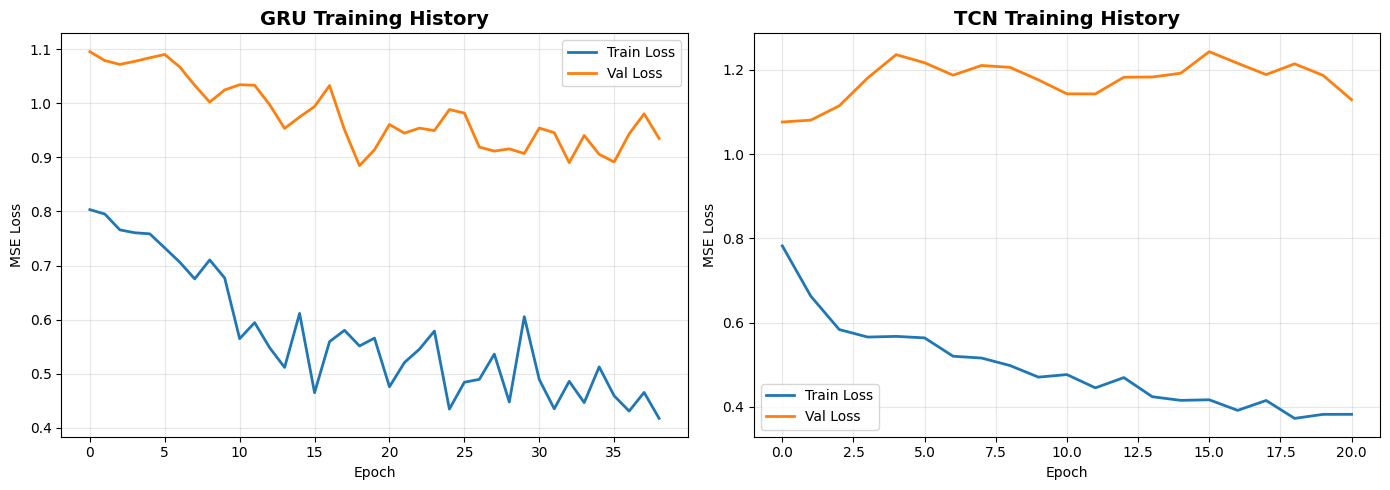


ALL MODELS SUCCESSFULLY TRAINED, EVALUATED & SAVED!

   Saved Models:
   - xgb_standalone_model.pkl
   - svm_standalone_model.pkl
   - gru_standalone_model.h5
   - tcn_standalone_model.h5
   - xgb_hybrid_model.pkl
   - svm_hybrid_model.pkl

   Saved Scalers:
   - scaler_classical.pkl
   - scaler_dl.pkl
   - scaler_hybrid.pkl

   All models ready for deployment!


In [3]:
"""
COMPLETE FLOOD PREDICTION SYSTEM - ALL MODELS INDIVIDUALLY TRAINED
===================================================================
This code will basically ensure that:
- Each model is trained INDIVIDUALLY and can work standalone
- All models are SAVED for deployment
- Clear separation between AIM 1, AIM 2, and AIM 3
- Proper evaluation of individual vs hybrid performance

"""

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, mean_absolute_error
import xgboost as xgb
import joblib

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import GRU, Dense, Dropout, Conv1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("COMPLETE FLOOD PREDICTION SYSTEM")
print("All Models Trained, Evaluated & Saved Individually")
print("=" * 80)

# ============================================================================
# STEP 0: LOAD DATA
# ============================================================================
print("\n[STEP 0] Loading Data from Google Colab...")

from google.colab import files
print(" Please upload the file:")
uploaded = files.upload()

df = pd.read_csv('final_model_data.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print(f"✓ Loaded {df.shape[0]} records from {df.index.min().date()} to {df.index.max().date()}")

# ============================================================================
# DATA PREPARATION
# ============================================================================
print("\n" + "=" * 80)
print("[DATA PREPARATION] Feature Engineering")
print("=" * 80)

# Rolling window features
df['river_rolling_mean_3'] = df['river_water_area_sqkm'].rolling(window=3).mean()
df['river_rolling_std_3'] = df['river_water_area_sqkm'].rolling(window=3).std()
df['rainfall_rolling_sum_3'] = df['rainfall_mm'].rolling(window=3).sum()
df['rainfall_rolling_mean_3'] = df['rainfall_mm'].rolling(window=3).mean()

# Lag features
df['river_lag_1'] = df['river_water_area_sqkm'].shift(1)
df['river_lag_2'] = df['river_water_area_sqkm'].shift(2)
df['rainfall_lag_1'] = df['rainfall_mm'].shift(1)
df['rainfall_lag_2'] = df['rainfall_mm'].shift(2)

# Change features
df['river_change'] = df['river_water_area_sqkm'].diff()
df['rainfall_change'] = df['rainfall_mm'].diff()

# Drop NaN
df = df.dropna()

# Define target
flood_threshold = df['river_water_area_sqkm'].quantile(0.85)
df['Flood_Event'] = (df['river_water_area_sqkm'] > flood_threshold).astype(int)

print(f"✓ Engineered {df.shape[1]} features")
print(f"✓ Flood threshold: {flood_threshold:.4f} sq km")
print(f"✓ Class distribution: {dict(df['Flood_Event'].value_counts())}")

# ============================================================================
# AIM 1: TRAIN INDIVIDUAL CLASSICAL ML MODELS (XGBoost & SVM)
# ============================================================================
print("\n" + "=" * 80)
print(" AIM 1: TRAIN CLASSICAL ML MODELS (STANDALONE)")
print("=" * 80)

# Define features for classical ML
geo_cols = ['mean_elevation_meters', 'mean_slope_degrees',
            'land_cover_class_10_percent', 'land_cover_class_20_percent',
            'land_cover_class_30_percent', 'land_cover_class_40_percent',
            'land_cover_class_50_percent', 'land_cover_class_60_percent',
            'land_cover_class_80_percent']

temporal_engineered = ['river_water_area_sqkm', 'rainfall_mm',
                       'river_rolling_mean_3', 'river_rolling_std_3',
                       'rainfall_rolling_sum_3', 'rainfall_rolling_mean_3',
                       'river_lag_1', 'river_lag_2',
                       'rainfall_lag_1', 'rainfall_lag_2',
                       'river_change', 'rainfall_change']

classical_features = temporal_engineered + geo_cols

X_classical = df[classical_features].copy()
y_classical = df['Flood_Event'].copy()

print(f"\n Classical ML Dataset:")
print(f"   Features: {len(classical_features)}")
print(f"   Samples: {len(X_classical)}")

# Train-test split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_classical, y_classical, test_size=0.2, random_state=42, stratify=y_classical
)

# Scaling
scaler_classical = StandardScaler()
X_train_cls_scaled = scaler_classical.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_classical.transform(X_test_cls)

# ─────────────────────────────────────────────────────────────────────────
# TRAIN MODEL 1: XGBoost (Standalone)
# ─────────────────────────────────────────────────────────────────────────
print("\n[1.1] Training XGBoost (Standalone Model)...")
xgb_standalone = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_standalone.fit(X_train_cls, y_train_cls)

# Evaluate
y_pred_xgb_standalone = xgb_standalone.predict(X_test_cls)
xgb_acc_standalone = accuracy_score(y_test_cls, y_pred_xgb_standalone)

print(f"✓ XGBoost Standalone Accuracy: {xgb_acc_standalone:.4f}")
print("\n Classification Report:")
print(classification_report(y_test_cls, y_pred_xgb_standalone, zero_division=0))

# Save model
joblib.dump(xgb_standalone, 'xgb_standalone_model.pkl')
joblib.dump(scaler_classical, 'scaler_classical.pkl')
print(" Saved: xgb_standalone_model.pkl, scaler_classical.pkl")

# ─────────────────────────────────────────────────────────────────────────
# TRAIN MODEL 2: SVM (Standalone)
# ─────────────────────────────────────────────────────────────────────────
print("\n[1.2] Training SVM (Standalone Model)...")
svm_standalone = SVC(kernel='rbf', C=10, gamma='scale', random_state=42, probability=True)
svm_standalone.fit(X_train_cls_scaled, y_train_cls)

# Evaluate
y_pred_svm_standalone = svm_standalone.predict(X_test_cls_scaled)
svm_acc_standalone = accuracy_score(y_test_cls, y_pred_svm_standalone)

print(f"✓ SVM Standalone Accuracy: {svm_acc_standalone:.4f}")
print("\n Classification Report:")
print(classification_report(y_test_cls, y_pred_svm_standalone, zero_division=0))

# Save model
joblib.dump(svm_standalone, 'svm_standalone_model.pkl')
print("Saved: svm_standalone_model.pkl")

print("\n" + "─" * 80)
print(" AIM 1 COMPLETE: Both classical models trained and saved!")
print("─" * 80)

# ============================================================================
# AIM 2: TRAIN INDIVIDUAL DEEP LEARNING MODELS (GRU & TCN)
# ============================================================================
print("\n" + "=" * 80)
print(" AIM 2: TRAIN DEEP LEARNING MODELS (STANDALONE)")
print("=" * 80)

# Prepare temporal sequences
temporal_cols = ['river_water_area_sqkm', 'rainfall_mm']
df_temporal = df[temporal_cols].values

# Scale
scaler_dl = StandardScaler()
df_temporal_scaled = scaler_dl.fit_transform(df_temporal)

def create_sequences(data, lookback=6, forecast_steps=1):
    """Create time-series sequences"""
    X, y = [], []
    for i in range(len(data) - lookback - forecast_steps + 1):
        X.append(data[i:(i + lookback)])
        y.append(data[i + lookback + forecast_steps - 1, 0])
    return np.array(X), np.array(y)

LOOKBACK = 6
FORECAST = 1

X_dl, y_dl = create_sequences(df_temporal_scaled, LOOKBACK, FORECAST)

print(f"\n Deep Learning Dataset:")
print(f"   Sequence shape: {X_dl.shape} (samples, timesteps, features)")
print(f"   Target shape: {y_dl.shape}")

# Split
split_idx = int(0.8 * len(X_dl))
X_train_dl = X_dl[:split_idx]
X_test_dl = X_dl[split_idx:]
y_train_dl = y_dl[:split_idx]
y_test_dl = y_dl[split_idx:]

print(f"   Train: {len(X_train_dl)}, Test: {len(X_test_dl)}")

# ─────────────────────────────────────────────────────────────────────────
# TRAIN MODEL 3: GRU (Standalone)
# ─────────────────────────────────────────────────────────────────────────
print("\n[2.1] Training GRU (Standalone Model)...")

gru_standalone = Sequential([
    GRU(64, activation='relu', return_sequences=True, input_shape=(LOOKBACK, 2)),
    Dropout(0.2),
    GRU(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
], name='GRU_Standalone')

gru_standalone.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

print("   Training in progress...")
gru_history = gru_standalone.fit(
    X_train_dl, y_train_dl,
    epochs=200,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# Evaluate
gru_pred_standalone = gru_standalone.predict(X_test_dl, verbose=0).flatten()
gru_mse = mean_squared_error(y_test_dl, gru_pred_standalone)
gru_mae = mean_absolute_error(y_test_dl, gru_pred_standalone)
gru_rmse = np.sqrt(gru_mse)

print(f"✓ GRU Standalone Performance:")
print(f"   MSE:  {gru_mse:.4f}")
print(f"   RMSE: {gru_rmse:.4f}")
print(f"   MAE:  {gru_mae:.4f}")
print(f"   Epochs trained: {len(gru_history.history['loss'])}")

# Save model
gru_standalone.save('gru_standalone_model.h5')
joblib.dump(scaler_dl, 'scaler_dl.pkl')
print(" Saved: gru_standalone_model.h5, scaler_dl.pkl")

# ─────────────────────────────────────────────────────────────────────────
# TRAIN MODEL 4: TCN (Standalone)
# ─────────────────────────────────────────────────────────────────────────
print("\n[2.2] Training TCN (Standalone Model)...")

tcn_standalone = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', padding='causal', input_shape=(LOOKBACK, 2)),
    Dropout(0.2),
    Conv1D(32, kernel_size=3, activation='relu', padding='causal'),
    Dropout(0.2),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(1)
], name='TCN_Standalone')

tcn_standalone.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

print("   Training in progress...")
tcn_history = tcn_standalone.fit(
    X_train_dl, y_train_dl,
    epochs=200,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# Evaluate
tcn_pred_standalone = tcn_standalone.predict(X_test_dl, verbose=0).flatten()
tcn_mse = mean_squared_error(y_test_dl, tcn_pred_standalone)
tcn_mae = mean_absolute_error(y_test_dl, tcn_pred_standalone)
tcn_rmse = np.sqrt(tcn_mse)

print(f"✓ TCN Standalone Performance:")
print(f"   MSE:  {tcn_mse:.4f}")
print(f"   RMSE: {tcn_rmse:.4f}")
print(f"   MAE:  {tcn_mae:.4f}")
print(f"   Epochs trained: {len(tcn_history.history['loss'])}")

# Save model
tcn_standalone.save('tcn_standalone_model.h5')
print(" Saved: tcn_standalone_model.h5")

print("\n" + "─" * 80)
print(" AIM 2 COMPLETE: Both DL models trained and saved!")
print("─" * 80)

# ============================================================================
# AIM 3: HYBRID MODELS (COMBINING CLASSICAL FEATURES + DL FORECASTS)
# ============================================================================
print("\n" + "=" * 80)
print(" AIM 3: TRAIN HYBRID MODELS (CLASSICAL + DL FORECASTS)")
print("=" * 80)

print("\n[3.1] Generating DL forecasts for entire dataset...")
# Generate forecasts using trained models
all_gru_forecasts = gru_standalone.predict(X_dl, verbose=0).flatten()
all_tcn_forecasts = tcn_standalone.predict(X_dl, verbose=0).flatten()

# Align datasets
align_idx = LOOKBACK + FORECAST - 1
X_hybrid = X_classical.iloc[align_idx:align_idx + len(all_gru_forecasts)].copy()
y_hybrid = y_classical.iloc[align_idx:align_idx + len(all_gru_forecasts)].copy()

# Add DL forecasts as NEW features
X_hybrid['GRU_Forecast'] = all_gru_forecasts
X_hybrid['TCN_Forecast'] = all_tcn_forecasts

print(f"\n Hybrid Dataset:")
print(f"   Original features: {len(classical_features)}")
print(f"   Added DL forecasts: 2 (GRU + TCN)")
print(f"   Total features: {X_hybrid.shape[1]}")
print(f"   Samples: {X_hybrid.shape[0]}")

# Split
X_train_hyb, X_test_hyb, y_train_hyb, y_test_hyb = train_test_split(
    X_hybrid, y_hybrid, test_size=0.2, random_state=42, stratify=y_hybrid
)

# Scale
scaler_hybrid = StandardScaler()
X_train_hyb_scaled = scaler_hybrid.fit_transform(X_train_hyb)
X_test_hyb_scaled = scaler_hybrid.transform(X_test_hyb)

# ─────────────────────────────────────────────────────────────────────────
# TRAIN MODEL 5: Hybrid XGBoost
# ─────────────────────────────────────────────────────────────────────────
print("\n[3.2] Training Hybrid XGBoost...")
xgb_hybrid = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_hybrid.fit(X_train_hyb, y_train_hyb)

y_pred_xgb_hybrid = xgb_hybrid.predict(X_test_hyb)
xgb_acc_hybrid = accuracy_score(y_test_hyb, y_pred_xgb_hybrid)

print(f"✓ Hybrid XGBoost Accuracy: {xgb_acc_hybrid:.4f}")
print(f"   Improvement: {xgb_acc_hybrid - xgb_acc_standalone:+.4f}")
print("\n Classification Report:")
print(classification_report(y_test_hyb, y_pred_xgb_hybrid, zero_division=0))

# Save
joblib.dump(xgb_hybrid, 'xgb_hybrid_model.pkl')
joblib.dump(scaler_hybrid, 'scaler_hybrid.pkl')
print("Saved: xgb_hybrid_model.pkl, scaler_hybrid.pkl")

# ─────────────────────────────────────────────────────────────────────────
# TRAIN MODEL 6: Hybrid SVM
# ─────────────────────────────────────────────────────────────────────────
print("\n[3.3] Training Hybrid SVM...")
svm_hybrid = SVC(kernel='rbf', C=10, gamma='scale', random_state=42, probability=True)
svm_hybrid.fit(X_train_hyb_scaled, y_train_hyb)

y_pred_svm_hybrid = svm_hybrid.predict(X_test_hyb_scaled)
svm_acc_hybrid = accuracy_score(y_test_hyb, y_pred_svm_hybrid)

print(f" Hybrid SVM Accuracy: {svm_acc_hybrid:.4f}")
print(f"   Improvement: {svm_acc_hybrid - svm_acc_standalone:+.4f}")
print("\n Classification Report:")
print(classification_report(y_test_hyb, y_pred_svm_hybrid, zero_division=0))

# Save
joblib.dump(svm_hybrid, 'svm_hybrid_model.pkl')
print(" Saved: svm_hybrid_model.pkl")

print("\n" + "─" * 80)
print(" AIM 3 COMPLETE: Both hybrid models trained and saved!")
print("─" * 80)

# ============================================================================
# FINAL COMPREHENSIVE RESULTS
# ============================================================================
print("\n" + "=" * 80)
print(" FINAL PERFORMANCE SUMMARY - ALL 6 MODELS")
print("=" * 80)

print("\n  AIM 1: Classical ML (Standalone)")
print(f"   1. XGBoost Standalone:  {xgb_acc_standalone:.4f}")
print(f"   2. SVM Standalone:      {svm_acc_standalone:.4f}")

print("\n  AIM 2: Deep Learning (Standalone - Forecasting)")
print(f"   3. GRU Standalone:  MSE={gru_mse:.4f}, RMSE={gru_rmse:.4f}, MAE={gru_mae:.4f}")
print(f"   4. TCN Standalone:  MSE={tcn_mse:.4f}, RMSE={tcn_rmse:.4f}, MAE={tcn_mae:.4f}")

print("\n AIM 3: Hybrid Models (Classical + DL)")
print(f"   5. Hybrid XGBoost:  {xgb_acc_hybrid:.4f}  (Δ: {xgb_acc_hybrid - xgb_acc_standalone:+.4f})")
print(f"   6. Hybrid SVM:      {svm_acc_hybrid:.4f}  (Δ: {svm_acc_hybrid - svm_acc_standalone:+.4f})")

# Feature importance
print("\n  Hybrid XGBoost - Top 10 Features:")
hybrid_imp = pd.DataFrame({
    'feature': X_hybrid.columns,
    'importance': xgb_hybrid.feature_importances_
}).sort_values('importance', ascending=False).head(10)
print(hybrid_imp.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(gru_history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(gru_history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('GRU Training History', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(tcn_history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(tcn_history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('TCN Training History', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("ALL MODELS SUCCESSFULLY TRAINED, EVALUATED & SAVED!")
print("=" * 80)
print("\n   Saved Models:")
print("   - xgb_standalone_model.pkl")
print("   - svm_standalone_model.pkl")
print("   - gru_standalone_model.h5")
print("   - tcn_standalone_model.h5")
print("   - xgb_hybrid_model.pkl")
print("   - svm_hybrid_model.pkl")
print("\n   Saved Scalers:")
print("   - scaler_classical.pkl")
print("   - scaler_dl.pkl")
print("   - scaler_hybrid.pkl")
print("\n   All models ready for deployment!")